# Dataset Description

This project uses the Iris Flower Dataset, one of the most well-known datasets in machine learning.

Source:
https://gist.githubusercontent.com/Thanatoz-1/9e7fdfb8189f0cdf5d73a494e4a6392a/raw/aaecbd14aeaa468cd749528f291aa8a30c2ea09e/iris_dataset.csv
Features:

Each row in the dataset represents a flower with the following measurements:

sepal_length – Length of the sepal (cm)
sepal_width – Width of the sepal (cm)
petal_length – Length of the petal (cm)
petal_width – Width of the petal (cm)
Target Classes:

The model predicts one of three flower species:

Setosa
Versicolor
Virginica
Dataset Size:
150 samples total
50 samples per class

# Installation

Make sure you have Python installed (preferably Python 3.8+), then install the required libraries:

In [ ]:
pip install torch pandas numpy scikit-learn matplotlib

# Importing the Necessary Libraries

In [38]:
# to work with dataframes
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch

# Model Architecture

This project uses a simple feedforward neural network (ANN):

Input layer: 4 neurons (features)

Hidden layers: Fully connected layers with activation functions

Output layer: 3 neurons (one for each class)


In [39]:
class Model(nn.Module):
  # input layer --> hidden layer --> ouput layer


  def __init__(self, input_features=4, h1=8, h2=9, out_features=3):
    super().__init__()
    self.fc1 = nn.Linear(input_features, h1)
    self.fc2 = nn.Linear(h1, h2)
    self.out = nn.Linear(h2, out_features)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.out(x)

    return x

In [40]:

torch.cuda.manual_seed_all(41)
model = Model()

# Load the dataset

In [42]:
url = 'https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
my_df = pd.read_csv( url)

In [43]:
my_df

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


# Converting Categorical Labels to Numerical Values

The variety column in the dataset contains text labels (flower names).
Machine learning models cannot work directly with text, so we convert them into numerical values.

In [44]:
my_df['variety'] = my_df['variety'].replace('Setosa', 0.0)
my_df['variety'] = my_df['variety'].replace('Virginica', 1.0)
my_df['variety'] = my_df['variety'].replace('Versicolor', 2.0)

/tmp/ipykernel_2224/3724849456.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['variety'] = my_df['variety'].replace('Versicolor', 2.0)


In [45]:
my_df.head()


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0


In [46]:
X = my_df.drop('variety', axis=1)
y = my_df['variety']


In [47]:
X

,sepal.length,sepal.width,petal.length,petal.width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [48]:
y

,variety
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
145,1.0
146,1.0
147,1.0
148,1.0


# Split the data

Training set --> used to train the model

Testing set --> used to evaluate how well the model performs on unseen data

In [49]:
X = X.values
y = y.values

In [51]:
X_train, X_test, y_trian, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

In [52]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

In [53]:
le = LabelEncoder()

y_trian = torch.LongTensor(le.fit_transform(y_trian))
y_test = torch.LongTensor(le.transform(y_test))

In [54]:
crtrion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [55]:
model.parameters

<bound method Module.parameters of Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)>

In [56]:
# Train the model
epochs = 100

losses =  []

for i in range(epochs):
  y_pred = model.forward(X_train)
  loss = crtrion(y_pred, y_trian)

  losses.append(loss.detach().numpy())

  if i % 10 == 0:
    print(f'Epoch: {i} Loss: {loss}')
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()


Epoch: 0 Loss: 1.1230332851409912
Epoch: 10 Loss: 0.9868019223213196
Epoch: 20 Loss: 0.7910900712013245
Epoch: 30 Loss: 0.5349666476249695
Epoch: 40 Loss: 0.36734673380851746
Epoch: 50 Loss: 0.25827112793922424
Epoch: 60 Loss: 0.16489405930042267
Epoch: 70 Loss: 0.10490269958972931
Epoch: 80 Loss: 0.07353097945451736
Epoch: 90 Loss: 0.057072415947914124


# Insights from the Training Loss Curve

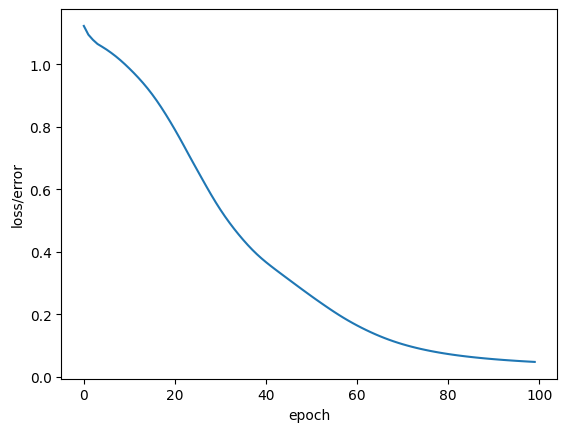

In [57]:
plt.plot(range(epochs), losses)
plt.ylabel('loss/error')
plt.xlabel('epoch')
plt.show()

Overall, this is a healthy training curve   your model is learning properly and approaching convergence without instability.

In [58]:
with torch.no_grad():
  y_eval = model.forward(X_test)
  loss = crtrion(y_eval, y_test)


In [59]:
loss

tensor(0.1310)

In [60]:
correct = 0

with torch.no_grad():
    for i, data in enumerate(X_test):
        y_val = model.forward(data)

        if y_test[i] == 0:
            x = 'Setosa'
        elif y_test[i] == 1:
            x = 'Versicolor'
        else:
            x = 'Virginica'

        # Will tell us what type of flower the network thinks it is
        print(f'{i+1}.) {str(y_val)} \t {y_test[i]} \t {y_val.argmax().item()}')

        # Correct or not
        if y_val.argmax().item() == y_test[i]:
            correct += 1

print(f'We got {correct} correct!')

1.) tensor([-4.9931,  7.6582,  4.8264]) 	 1 	 1
2.) tensor([-7.2427, 11.2206,  4.8422]) 	 1 	 1
3.) tensor([-7.4353, 11.5755,  5.6521]) 	 1 	 1
4.) tensor([-1.3432,  1.7931,  5.5182]) 	 2 	 2
5.) tensor([-5.9918,  9.2436,  5.3144]) 	 1 	 1
6.) tensor([ 0.5835, -1.2924,  5.6281]) 	 2 	 2
7.) tensor([-4.2528,  6.4566,  5.1497]) 	 1 	 1
8.) tensor([-1.0278,  1.2694,  5.5718]) 	 2 	 2
9.) tensor([-5.0509,  7.7297,  5.2497]) 	 1 	 1
10.) tensor([-7.5655, 11.7429,  5.1575]) 	 1 	 1
11.) tensor([-3.8727,  5.8366,  5.1803]) 	 1 	 1
12.) tensor([ 10.9993, -16.5705,   5.3672]) 	 0 	 0
13.) tensor([  9.9204, -14.9774,   4.8209]) 	 0 	 0
14.) tensor([ 1.3297, -2.4979,  4.9599]) 	 2 	 2
15.) tensor([  9.3624, -14.2436,   5.3220]) 	 0 	 0
16.) tensor([-3.5422,  5.3272,  5.3476]) 	 1 	 2
17.) tensor([  9.8137, -14.8555,   5.1280]) 	 0 	 0
18.) tensor([-4.5880,  6.9956,  5.0179]) 	 2 	 1
19.) tensor([ 11.6880, -17.5483,   5.3147]) 	 0 	 0
20.) tensor([  8.4554, -12.8622,   4.6494]) 	 0 	 0
21.) tensor

In [61]:
new_iris = torch.tensor([4.7, 3.2, 1.3, 0.2], dtype=torch.float32)


In [62]:
with torch.no_grad():
  print(model(new_iris))



tensor([ 10.6603, -16.0550,   5.0481])


In [63]:
with torch.no_grad():
  print(model(new_iris))

tensor([ 10.6603, -16.0550,   5.0481])


In [64]:
newer_iris = torch.tensor([5.0, 3.6, 1.4, 0.2	], dtype=torch.float32)


In [65]:
with torch.no_grad():
  print(model(newer_iris))

tensor([ 11.5032, -17.2914,   5.3534])


In [66]:
newer_iris2 = torch.tensor([4.6, 3.1, 1.5, 0.2	], dtype=torch.float32)

In [67]:
with torch.no_grad():
  print(model(newer_iris2))

tensor([  9.8271, -14.8631,   4.9985])


In [68]:
# Save the NN Model
torch.save(model.state_dict(), 'iris_nn.pt')

In [69]:
# Load the Saved Model

new_model = Model()
new_model.load_state_dict(torch.load('iris_nn.pt'))


<All keys matched successfully>

In [70]:
# Make sure it loaded correctly
new_model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)

# Project Summary

This project focuses on building a machine learning classification model using PyTorch to identify different species of iris flowers.

The model is trained on the Iris dataset, which contains measurements of flower features such as sepal length, sepal width, petal length, and petal width. These features are used to classify flowers into three categories: Setosa, Versicolor, and Virginica.

**During the process:**

The dataset was preprocessed by converting categorical labels into numerical values
The data was split into training and testing sets
A feedforward neural network was designed and trained over multiple epochs
Model performance was evaluated using test data

The training results show a steady decrease in loss, indicating that the model successfully learns patterns from the data and improves its predictions over time.